<a href="https://colab.research.google.com/github/tarynglover/tarynglover_INFO4670_Spring2026/blob/main/Assignment_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [16]:
# Write your code here

from google.colab import files
uploaded = files.upload()


Saving Assignment 2 dataset.csv to Assignment 2 dataset (2).csv


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# I want to use df

for filename in uploaded.keys():
    df = pd.read_csv(filename)
    print(f"Loaded file: {filename}")

df.head()


Loaded file: Assignment 2 dataset (2).csv


,Column 1,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12-27-2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12-20-2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12-13-2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12-6-2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11-29-2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Region Distribution:
region
WestTexNewMexico       340
Albany                 338
BaltimoreWashington    338
Boise                  338
Boston                 338
Atlanta                338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
BuffaloRochester       338
LasVegas               338
LosAngeles             338
MiamiFtLauderdale      338
Louisville             338
Nashville              338
NewOrleansMobile       338
NewYork                338
Midsouth               338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338


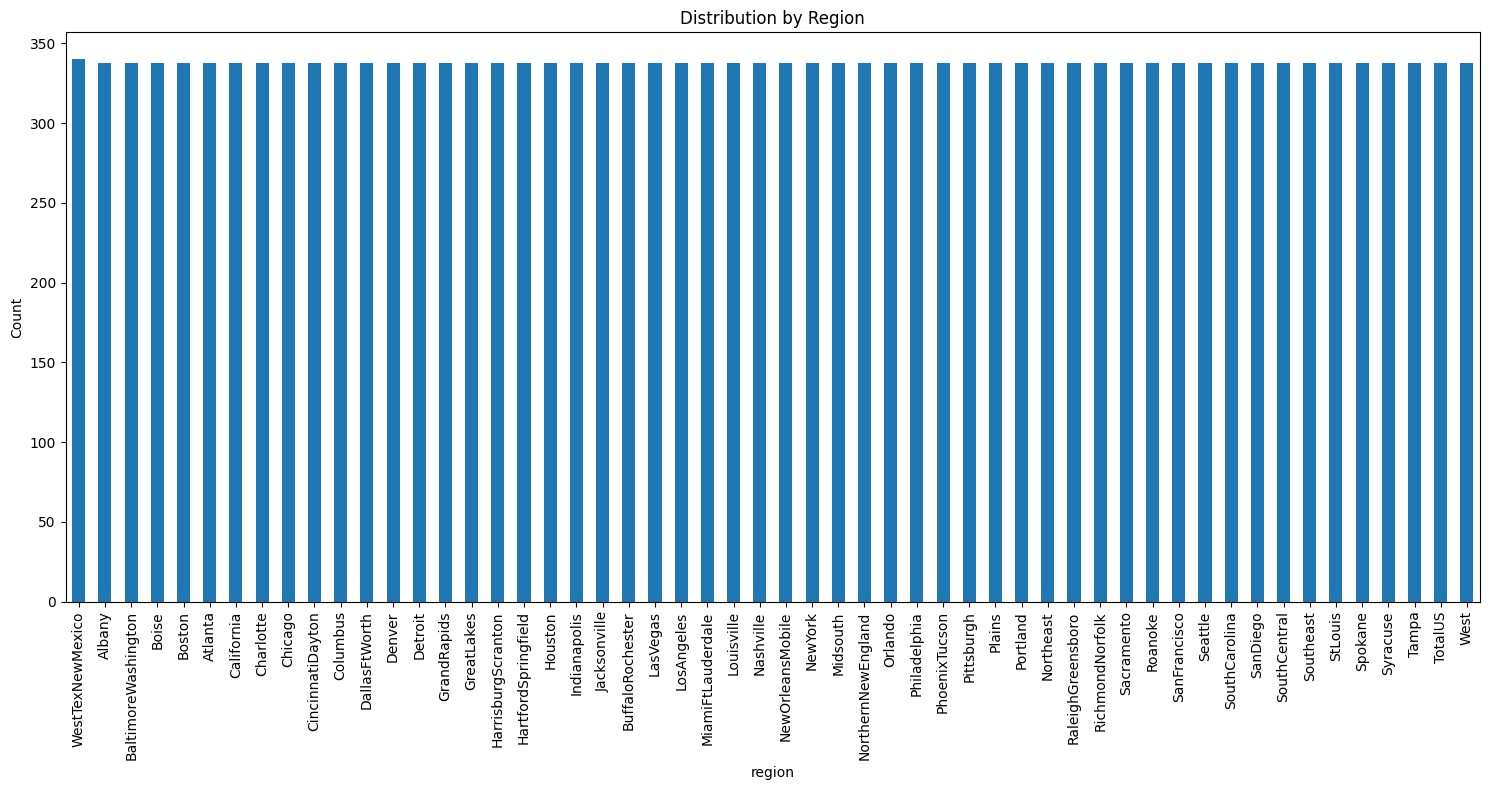

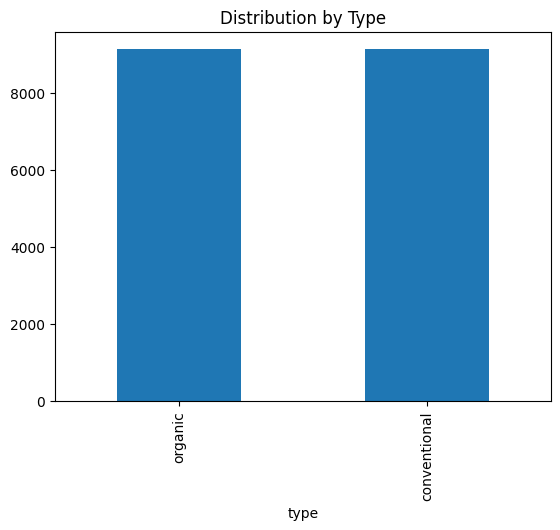

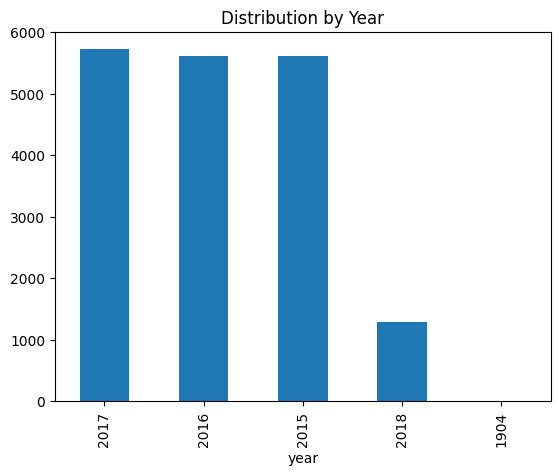

In [18]:
print("Region Distribution:")
print(df['region'].value_counts())

print("\nType Distribution:")
print(df['type'].value_counts())

print("\nYear Distribution:")
print(df['year'].value_counts())

# Plot Region
plt.figure(figsize=(15, 8))
df['region'].value_counts().plot(kind='bar')
plt.xticks(rotation=90)
plt.title("Distribution by Region")
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot Type
plt.figure()
df['type'].value_counts().plot(kind='bar')
plt.title("Distribution by Type")
plt.show()

# Plot Year
plt.figure()
df['year'].value_counts().plot(kind='bar')
plt.title("Distribution by Year")
plt.show()

The dataset seems well balanced across region and type, meaning no major class imbalance issue. But the 1904 entry suggests a data quality issue that should be addressed.

1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [19]:
#duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

#missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Number of duplicate rows: 2

Missing values per column:
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64


For the issue of duplicate rows, there are only 2 so I would remove one. If a row were to be missing most of its values, I'd remove it. Otherwise, I would replace those missing values with a median of the value from the same region. I think this choice would conserve the integrity of the data and be preferable to removing rows.


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [20]:
print("Dataset shape:", df.shape)


Dataset shape: (18254, 14)


I think the dataset is a significant size to train a model. 18,000 samples should provide enough for a good train/test split.

#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [21]:
#remove the first column

df = df.drop(columns=['Column 1'])
print("Updated columns:")
print(df.columns)

#year is nominal
df['year'] = df['year'].astype('category')

print("\nData types:")
print(df.dtypes)


Updated columns:
Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='object')

Data types:
Date              object
AveragePrice     float64
Total Volume     float64
4046             float64
4225             float64
4770             float64
Total Bags       float64
Small Bags       float64
Large Bags       float64
XLarge Bags      float64
type              object
year            category
region            object
dtype: object


2.2 Check for duplicate values and remove them.

In [22]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (18252, 13)


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [23]:
# Remove rows with more than 50% missing values
df = df[df.isnull().mean(axis=1) < 0.5]

# Fill remaining numeric missing values using median by region
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df.groupby('region')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


Correlation Matrix:
              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192767 -0.208325 -0.172944 -0.179458   
Total Volume     -0.192767      1.000000  0.977863  0.974181  0.872203   
4046             -0.208325      0.977863  1.000000  0.926110  0.833390   
4225             -0.172944      0.974181  0.926110  1.000000  0.887856   
4770             -0.179458      0.872203  0.833390  0.887856  1.000000   
Total Bags       -0.177103      0.963047  0.920057  0.905788  0.792315   
Small Bags       -0.174742      0.967238  0.925280  0.916032  0.802734   
Large Bags       -0.172953      0.880640  0.838646  0.810016  0.698473   
XLarge Bags      -0.117604      0.747158  0.699378  0.688810  0.679862   

              Total Bags  Small Bags  Large Bags  XLarge Bags  
AveragePrice   -0.177103   -0.174742   -0.172953    -0.117604  
Total Volume    0.963047    0.967238    0.880640     0.747158  
4046            0.920057    0.925280    0.83864

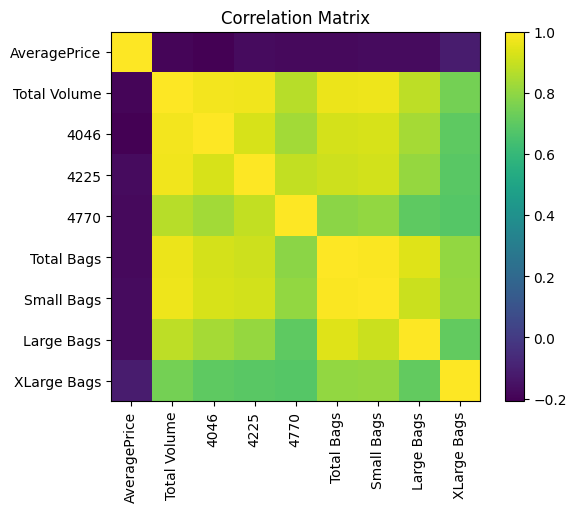

In [24]:
correlation_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure()
plt.imshow(correlation_matrix)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


I can see a high correlation between total volume and 4046, 4225, 4770, and bag quantities. Also total bags and Small, Large, and XLarge Bags. These make sense because theyre both the sum of those components and therfore directly mathmatically related. In a linear regression model, this may lead to overfitting.

#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

In [25]:
#continuous variables
print("Descriptive Statistics:")
print(df.describe())

#categorical variables
print("\nCategorical Variables:")
for col in df.select_dtypes(include=['object','category']).columns:
    print(f"{col}:")
    print(df[col].unique())
    print()


Descriptive Statistics:
       AveragePrice  Total Volume          4046          4225          4770  \
count  18251.000000  1.825100e+04  1.825100e+04  1.825100e+04  1.825100e+04   
mean       1.406020  8.505523e+05  2.929840e+05  2.951225e+05  2.283727e+04   
std        0.402675  3.453367e+06  1.264922e+06  1.204058e+06  1.074584e+05   
min        0.440000  8.456000e+01  0.000000e+00  0.000000e+00  0.000000e+00   
25%        1.100000  1.084067e+04  8.543500e+02  3.008325e+03  0.000000e+00   
50%        1.370000  1.073542e+05  8.645300e+03  2.905673e+04  1.849900e+02   
75%        1.660000  4.329430e+05  1.110375e+05  1.501258e+05  6.240690e+03   
max        3.250000  6.250565e+07  2.274362e+07  2.047057e+07  2.546439e+06   

         Total Bags    Small Bags    Large Bags    XLarge Bags  
count  1.825100e+04  1.825100e+04  1.825100e+04   18251.000000  
mean   2.396140e+05  1.821784e+05  5.433233e+04    3106.086096  
std    9.861913e+05  7.461393e+05  2.439532e+05   17691.955036  
min 

3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [26]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Earliest date
earliest_date = df['Date'].min()
print("Earliest Date:", earliest_date)

# Check for data before 2010
before_2010 = df[df['Date'].dt.year < 2010]
print("Number of records before 2010:", len(before_2010))

before_2010.head()



Earliest Date: 1904-01-21 00:00:00
Number of records before 2010: 1


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
18250,1904-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.8,42.31,0.0,organic,1904,WestTexNewMexico


This date is such an extreme outlier that I would remove it

3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [27]:
max_price = df['AveragePrice'].max()
region_max_price = df.loc[df['AveragePrice'].idxmax(), 'region']

print("Highest Average Price:", max_price)
print("Region with Highest Average Price:", region_max_price)


Highest Average Price: 3.25
Region with Highest Average Price: SanFrancisco


using the 'max' function to parse through the average price column to find the highest average price. Then using the index position of the max to find out the corresponding region.


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [28]:
max_volume = df['Total Volume'].max()
region_max_volume = df.loc[df['Total Volume'].idxmax(), 'region']

print("Highest Total Volume:", max_volume)
print("Region with Highest Total Volume:", region_max_volume)


Highest Total Volume: 62505646.52
Region with Highest Total Volume: TotalUS


Used to max function to locate the highest value of the total volume column. Total US had the highest volume b ecause it combines every region’s avocado sales